In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.shape

(99441, 8)

In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [6]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [7]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


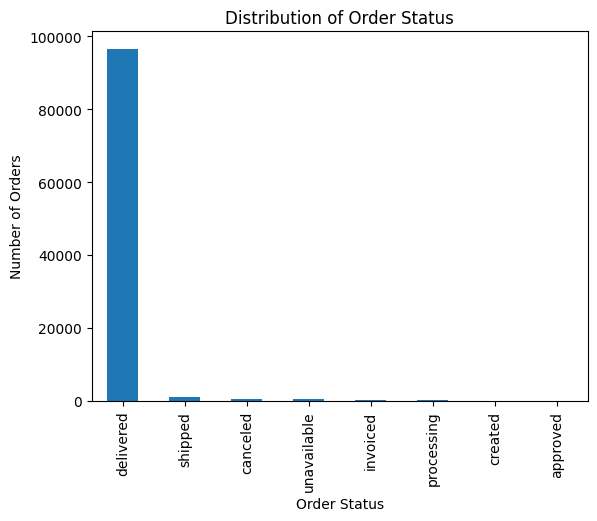

In [9]:
import matplotlib.pyplot as plt

orders["order_status"].value_counts().plot(kind="bar")

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

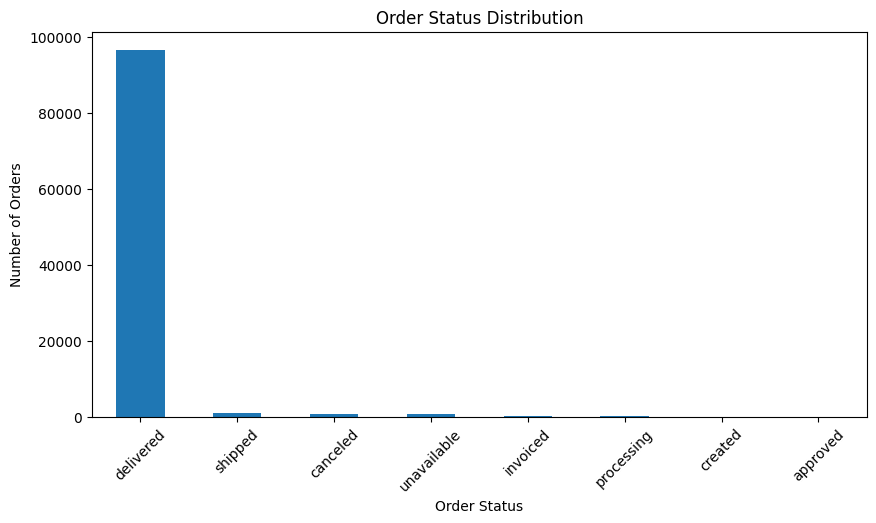

In [10]:
import matplotlib.pyplot as plt

status_counts = orders["order_status"].value_counts()

plt.figure(figsize=(10,5))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [11]:
delivered = (orders["order_status"] == "delivered").sum()

total_orders = len(orders)

delivery_rate = (delivered / total_orders) * 100

print(f"Delivery Success Rate: {delivery_rate:.2f}%")

Delivery Success Rate: 97.02%


In [12]:
delivered = (orders["order_status"] == "delivered").sum()

total_orders = len(orders)

delivery_rate = (delivered / total_orders) * 100

print(f"Total Orders: {total_orders}")
print(f"Delivered Orders: {delivered}")
print(f"Delivery Success Rate: {delivery_rate:.2f}%")

Total Orders: 99441
Delivered Orders: 96478
Delivery Success Rate: 97.02%


In [13]:
delivered = (orders["order_status"] == "delivered").sum()

In [14]:
cancelled = (orders["order_status"] == "canceled").sum()

cancel_rate = (cancelled / total_orders) * 100

print(f"Cancelled Orders: {cancelled}")
print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancelled Orders: 625
Cancellation Rate: 0.63%


In [15]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

In [16]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

In [17]:
average_delivery = orders["delivery_days"].mean()

print(f"Average Delivery Time: {average_delivery:.2f} days")

Average Delivery Time: 12.09 days


In [18]:
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [19]:
orders["late_delivery"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

In [20]:
late_orders = orders["late_delivery"].sum()

late_rate = (late_orders / delivered) * 100

print(f"Late Deliveries: {late_orders}")
print(f"Late Delivery Rate: {late_rate:.2f}%")

Late Deliveries: 7827
Late Delivery Rate: 8.11%


In [21]:
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [22]:
orders["late_delivery"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

In [23]:
late_orders = orders["late_delivery"].sum()

late_rate = (late_orders / delivered) * 100

print(f"Late Deliveries: {late_orders}")
print(f"Late Delivery Rate: {late_rate:.2f}%")

Late Deliveries: 7827
Late Delivery Rate: 8.11%


In [24]:
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [25]:
orders["late_delivery"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

In [26]:
late_orders = orders["late_delivery"].sum()

late_rate = (late_orders / delivered) * 100

print(f"Late Deliveries: {late_orders}")
print(f"Late Delivery Rate: {late_rate:.2f}%")

Late Deliveries: 7827
Late Delivery Rate: 8.11%
